# Visualization - Four-Day Weeks as Solution to Childcare Costs

## Code Attribution 
<ul>
  <li> Title: Matplotlib Tutorials
  <li> Author: Matplotlib
  <li> Date: 8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Code offers basics of how to create visualizaitons in Matplotlib 

<ul>
  <li> Title: The Data Wrangling Workshop
  <li> Author: Brian Lipp, Shubhadeep Roychowdhury, Dr. Tirthajyoti Sarkar
  <li> Date:  8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Data Sources & Data Wrangling

<ul>
  <li> Title: Trial Statistics Horizontal Bar Chart
  <li> Author: Perplexity AI
  <li> Date:  8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Uses simulated trial data to create Papillion color-themed
      horizontal bar chart

<ul>
  <li> Title: Slider Widget
  <li> Author: GeeksforGeeks
  <li> Date:  8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: The slider provides control over the visual properties of the plot

<ul>
  <li> Title: Waffle Chart with Additional Grouping
  <li> Author: python-graph-gallery.com
  <li> Date:  8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: A waffle chart is a graphical representation of data points in a dataset, where individual data points are represented by small squares on a two-dimensional grid

<ul>
  <li> Title: Dash in 20 Minutes Tutorial
  <li> Author: https://dash.plotly.com/tutorial
  <li> Date:  8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: By the end of this tutorial, you will understand the basic building blocks of Dash

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
%matplotlib widget
import numpy as np
from matplotlib.widgets import Slider
from pywaffle import Waffle
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.backends.backend_agg import FigureCanvasAgg
import matplotlib.pyplot as plt
import io
import base64
from dash import Dash, html, dcc, callback, Output, Input

In [2]:
updated_childcare_df = pd.read_excel('NDCP2022.xlsx')

In [3]:
updated_childcare_df.head()

,STATE_NAME,STATE_ABBREVIATION,COUNTY_NAME,COUNTY_FIPS_CODE,STUDYYEAR,EMR_16,FEMR_16,MEMR_16,EMR_20to64,FEMR_20to64,...,iFEMP_SERVICE_STATE,iEMP_SALES_STATE,iMEMP_SALES_STATE,iFEMP_SALES_STATE,iEMP_N_STATE,iMEMP_N_STATE,iFEMP_N_STATE,iEMP_P_STATE,iMEMP_P_STATE,iFEMP_P_STATE
0,Alabama,AL,Autauga County,1001,2008,61.5,56.1,67.3,71.4,66.3,...,1,1,1,1,1,1,1,1,1,1
1,Alabama,AL,Autauga County,1001,2009,60.6,54.8,67.0,72.5,66.9,...,1,1,1,1,1,1,1,1,1,1
2,Alabama,AL,Autauga County,1001,2010,60.4,54.9,66.4,72.3,67.4,...,1,1,1,1,1,1,1,1,1,1
3,Alabama,AL,Autauga County,1001,2011,58.7,52.4,65.6,71.0,64.9,...,1,1,1,1,1,1,1,1,1,1
4,Alabama,AL,Autauga County,1001,2012,57.7,52.2,63.8,70.7,65.1,...,1,1,1,1,1,1,1,1,1,1


In [4]:
updated_childcare_df.columns

Index(['STATE_NAME', 'STATE_ABBREVIATION', 'COUNTY_NAME', 'COUNTY_FIPS_CODE',
       'STUDYYEAR', 'EMR_16', 'FEMR_16', 'MEMR_16', 'EMR_20to64',
       'FEMR_20to64',
       ...
       'iFEMP_SERVICE_STATE', 'iEMP_SALES_STATE', 'iMEMP_SALES_STATE',
       'iFEMP_SALES_STATE', 'iEMP_N_STATE', 'iMEMP_N_STATE', 'iFEMP_N_STATE',
       'iEMP_P_STATE', 'iMEMP_P_STATE', 'iFEMP_P_STATE'],
      dtype='object', length=370)

In [5]:
sarpy_2022 = updated_childcare_df[
    (updated_childcare_df["STATE_ABBREVIATION"] == "NE") &
    (updated_childcare_df["COUNTY_NAME"].str.contains("Sarpy", case=False))
]

In [6]:
sarpy_2022.head()

,STATE_NAME,STATE_ABBREVIATION,COUNTY_NAME,COUNTY_FIPS_CODE,STUDYYEAR,EMR_16,FEMR_16,MEMR_16,EMR_20to64,FEMR_20to64,...,iFEMP_SERVICE_STATE,iEMP_SALES_STATE,iMEMP_SALES_STATE,iFEMP_SALES_STATE,iEMP_N_STATE,iMEMP_N_STATE,iFEMP_N_STATE,iEMP_P_STATE,iMEMP_P_STATE,iFEMP_P_STATE
25952,Nebraska,NE,Sarpy County,31153,2008,69.9,66.3,73.7,78.4,75.4,...,1,1,1,1,1,1,1,1,1,1
25953,Nebraska,NE,Sarpy County,31153,2009,69.9,66.5,73.5,78.4,75.4,...,1,1,1,1,1,1,1,1,1,1
25954,Nebraska,NE,Sarpy County,31153,2010,70.7,67.6,73.8,79.4,76.8,...,1,1,1,1,1,1,1,1,1,1
25955,Nebraska,NE,Sarpy County,31153,2011,70.4,67.8,73.1,79.6,77.3,...,1,1,1,1,1,1,1,1,1,1
25956,Nebraska,NE,Sarpy County,31153,2012,70.1,67.5,72.9,79.6,49.1,...,1,1,1,1,1,1,1,1,1,1


## Medium One: Dashboard Story Board

### Childcare Costs as Percentage of Sarpy County Median Income 

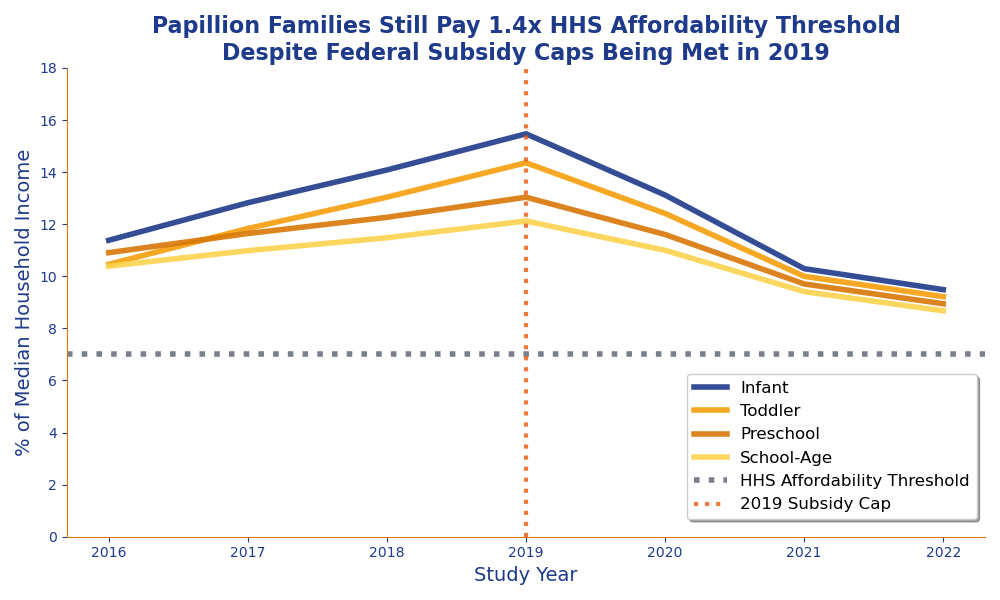

In [7]:
# Creates map with Papillion city colors
papillion_colors = {
    'Infant': '#1E3A8A',      
    'Toddler': '#F59E0B',     
    'Preschool': '#D97706',  
    'School-Age': '#FCD34D',  
    'projected': '#DC2626',   
    'hhs_threshold': '#6B7280',
    'subsidy_cap': '#EA580C'  
}

# Filters dataframe for Sarpy County values
sarpy_data = sarpy_2022[sarpy_2022['COUNTY_NAME'] == 'Sarpy County']
price_cols = ['_75FCCINFANT', '_75FCCTODDLER', '_75FCCPRESCHOOL', '_75FCCSA']

# Creates column mapping for plotting
col_mapping = {'_75FCCINFANT': 'Infant', '_75FCCTODDLER': 'Toddler', 
               '_75FCCPRESCHOOL': 'Preschool', '_75FCCSA': 'School-Age'}

# Calculates yearly proportions
proportions = (sarpy_data.groupby('STUDYYEAR')[price_cols].median() * 52).div(
    sarpy_data.groupby('STUDYYEAR')['MHI'].median(), axis=0) * 100
proportions.columns = [col_mapping[col] for col in proportions.columns]

fig, ax = plt.subplots(figsize=(10,6), facecolor='white')

# Plots lines by age group
for i, col in enumerate(proportions.columns):
    proportions[col].plot(ax=ax, linewidth=4, 
                         color=papillion_colors[col], alpha=0.9, 
                         label=col)

# Includes lines to accentuate affordability threshold and 2019 subsidy cap
ax.axhline(y=7, color=papillion_colors['hhs_threshold'], linestyle=':', 
           linewidth=4, alpha=0.9, label='HHS Affordability Threshold')
ax.axvline(x=2019, color=papillion_colors['subsidy_cap'], linestyle=':', 
           linewidth=3, alpha=0.8, label='2019 Subsidy Cap')

ax.set_ylim(0, 18)
ax.set_title('Papillion Families Still Pay 1.4x HHS Affordability Threshold\n\
Despite Federal Subsidy Caps Being Met in 2019', 
             fontweight='bold', fontsize=16, color='#1E3A8A')
ax.set_ylabel('% of Median Household Income', fontsize=14, color='#1E3A8A')
ax.set_xlabel('Study Year', fontsize=14, color='#1E3A8A')

# Legend with Papillion styling
ax.legend(bbox_to_anchor=(1,.02), loc='lower right', frameon=True, 
          fancybox=True, shadow=True, fontsize=12, facecolor='white')

# Grid and ticks
ax.tick_params(colors='#1E3A8A')
ax.spines['bottom'].set_color('#D97706')
ax.spines['left'].set_color('#D97706')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks()
plt.tight_layout()
plt.show()

### Trial Financial Statistics Horizontal Bar Chart 

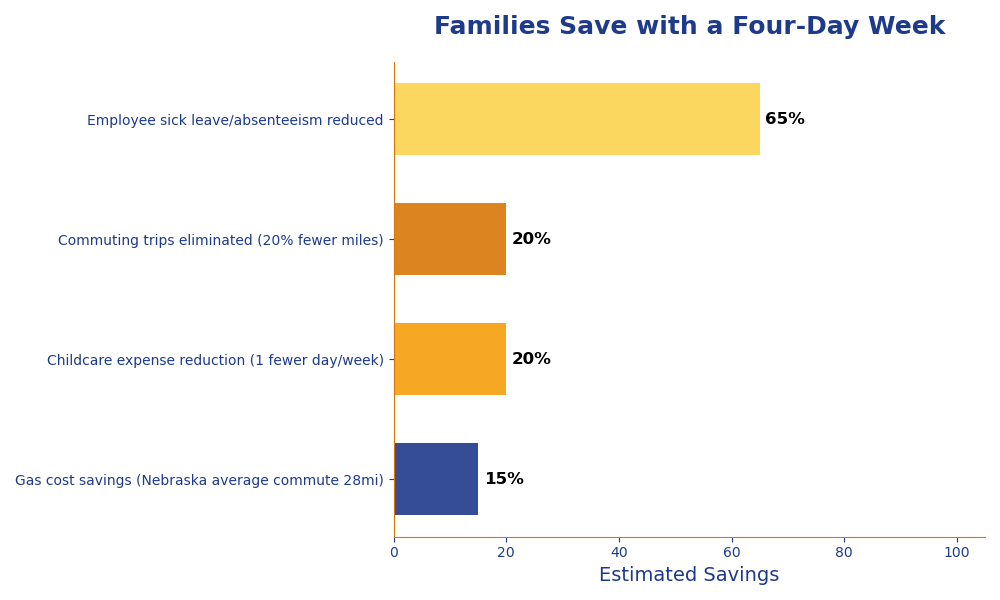

In [8]:
# Creates 4-day week trial data using Perplexity AI simulated data
trial_data = pd.DataFrame({
    'Family Savings Metric': [
        'Childcare expense reduction (1 fewer day/week)',
        'Employee sick leave/absenteeism reduced',
        'Commuting trips eliminated (20% fewer miles)', 
        'Gas cost savings (Nebraska average commute 28mi)'
    ],
    'Estimated Savings': [20, 65, 20, 15]
})

trial_data = trial_data.sort_values('Estimated Savings', ascending=True).reset_index(drop=True)

# Continues Papillion Color Scheme
papillion_colors = ['#1E3A8A', '#F59E0B', '#D97706', '#FCD34D', '#60A5FA', '#FDBA74']

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

bars = ax.barh(trial_data['Family Savings Metric'], trial_data['Estimated Savings'], 
               color=papillion_colors, alpha=0.9, height=0.6)

ax.set_xlim(0, 105)
ax.set_title('Families Save with a Four-Day Week', 
             fontweight='bold', fontsize=18, pad=20, color='#1E3A8A')
ax.set_xlabel('Estimated Savings', fontsize=14, color='#1E3A8A')
ax.set_ylabel('')

# Includes simulated trial labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{width}%', ha='left', va='center', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#D97706')
ax.spines['left'].set_color('#D97706')
ax.tick_params(colors='#1E3A8A')

plt.tight_layout()
plt.show()

### Interactive Dollars and Time Saved Plots

In [9]:
# Filters into only 2022 data
sarpy_2022_data = sarpy_data[sarpy_data['STUDYYEAR'] == 2022]

# Extracts only the first row containing all 2022 data
sarpy_2022_row = sarpy_2022_data.iloc[0]  

# Maps weekly costs from dataframe to ages
weekly_costs = {
    0: sarpy_2022_row['_75FCCINFANT'],      
    1: sarpy_2022_row['_75FCCTODDLER'],       
    3: sarpy_2022_row['_75FCCPRESCHOOL'],   
    6: sarpy_2022_row['_75FCCSA'],          
    12: sarpy_2022_row['_75FCCSA'] * 0.5    
}

# Establishes colors to be used
papillion_colors = {'saved': '#F59E0B', 'background': '#FCD34D'}

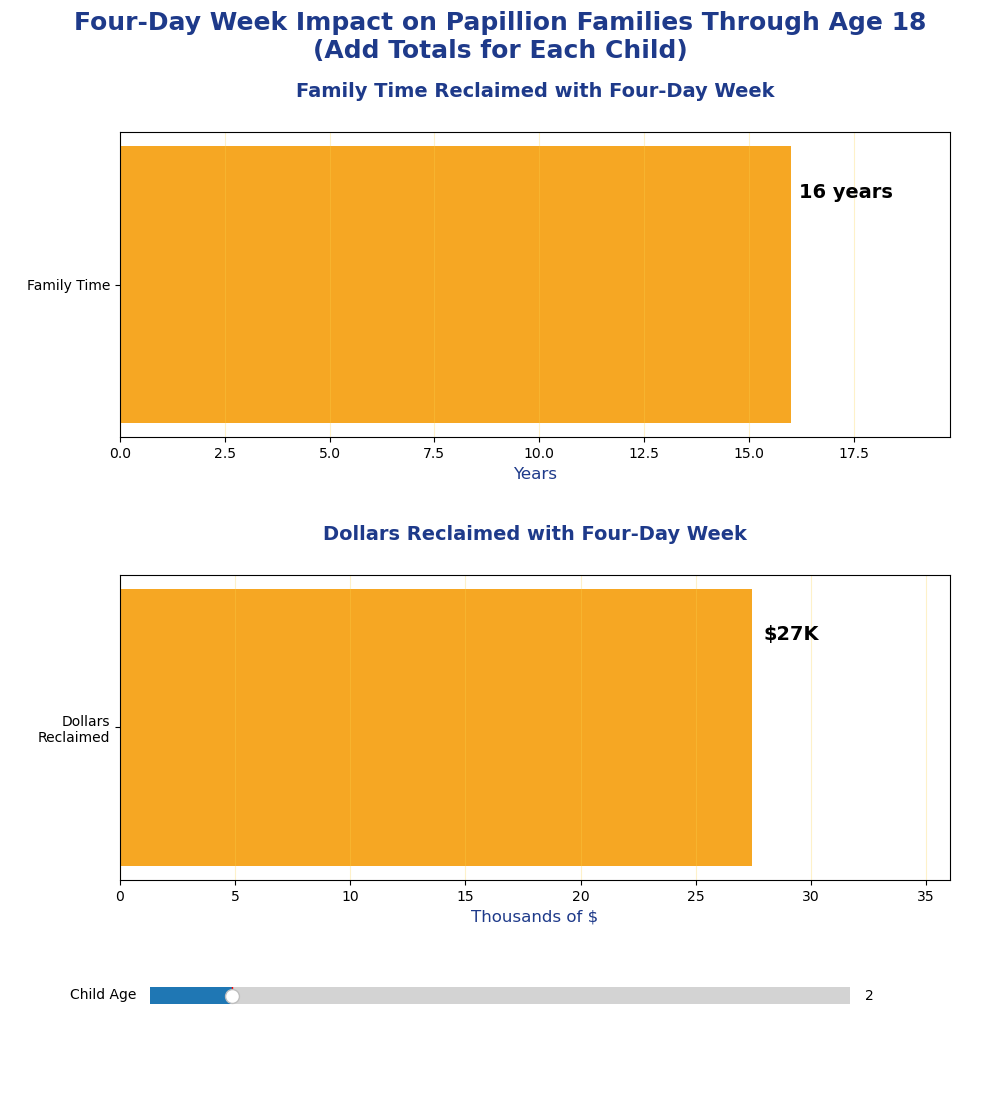

In [10]:
# Creates figure with two row subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 11), 
                               gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.45})
fig.patch.set_facecolor('white')

# Establishes age slider will start at
current_age = 2

def get_weekly_cost(age):
    """Gets Sarpy 2022 weekly cost for age from weekly_costs map"""
    ages = sorted(weekly_costs.keys())
    for i, a in enumerate(ages):
        if age <= a:
            return weekly_costs[a]
    return weekly_costs[ages[-1]]

def calculate_values(age):
    years_remaining = max(0, 18 - age)
    
    weekly_cost = get_weekly_cost(age)
    weekly_savings = weekly_cost * 0.2  
    total_dollars = years_remaining * weekly_savings * 52 / 1000  
    
    return years_remaining, total_dollars

# Calculates initial values 
max_years, max_dollars = calculate_values(0)
years_remaining, total_dollars = calculate_values(current_age)

# Establishes time chart details
ax1.set_xlim(0, max_years * 1.1)
years_bar = ax1.barh(['Family Time'], [years_remaining], 
                     color=papillion_colors['saved'], alpha=0.9, height=0.6)
ax1.set_title('Family Time Reclaimed with Four-Day Week', 
              fontweight='bold', fontsize=14, color='#1E3A8A', pad=25)
ax1.set_xlabel('Years', fontsize=12, color='#1E3A8A')
ax1.grid(True, axis='x', alpha=0.3, color=papillion_colors['background'])
years_text = ax1.text(years_remaining + 0.2, 0.2, f'{years_remaining:.0f} years', 
                      ha='left', va='center', fontweight='bold', fontsize=14)

# Establishes dollar chart details
ax2.set_xlim(0, max_dollars * 1.1)
dollars_bar = ax2.barh(['Dollars\nReclaimed'], [total_dollars], 
                      color=papillion_colors['saved'], alpha=0.9, height=0.6)
ax2.set_title('Dollars Reclaimed with Four-Day Week', 
              fontweight='bold', fontsize=14, color='#1E3A8A', pad=25)
ax2.set_xlabel('Thousands of $', fontsize=12, color='#1E3A8A')
ax2.grid(True, axis='x', alpha=0.3, color=papillion_colors['background'])
dollars_text = ax2.text(total_dollars + 0.5, 0.2, f'${total_dollars:.0f}K', 
                       ha='left', va='center', fontweight='bold', fontsize=14)

fig.suptitle('Four-Day Week Impact on Papillion Families Through Age 18\n(Add Totals for Each Child)', 
             fontsize=18, fontweight='bold', color='#1E3A8A', y=0.99)

plt.subplots_adjust(left=0.12, right=0.95, top=0.88, bottom=0.20)

# Creates interactive slider 
ax_slider = plt.axes([0.15, 0.08, 0.7, 0.03])
age_slider = Slider(ax_slider, 'Child Age', 0, 17, valinit=current_age, valstep=1)

def update(val):
    age = int(age_slider.val)
    years_val, dollars_val = calculate_values(age)
    
    # Updates years bar and text
    years_bar[0].set_width(years_val)
    years_text.set_position((years_val + 0.2, 0.2))
    years_text.set_text(f'{years_val:.0f} years')
    
    # Updates dollars bar and text
    dollars_bar[0].set_width(dollars_val)
    dollars_text.set_position((dollars_val + 0.5, 0.2))
    dollars_text.set_text(f'${dollars_val:.0f}K')
    
    # Shows actual Sarpy 2022 weekly cost from data
    weekly_cost = get_weekly_cost(age)
    ax_slider.label.set_text(f'Child Age (${weekly_cost:.0f}/wk Sarpy 2022)')
    
    fig.canvas.draw_idle()

age_slider.on_changed(update)
plt.show()

## Medium Two: Infographic

### Household Composition Pies

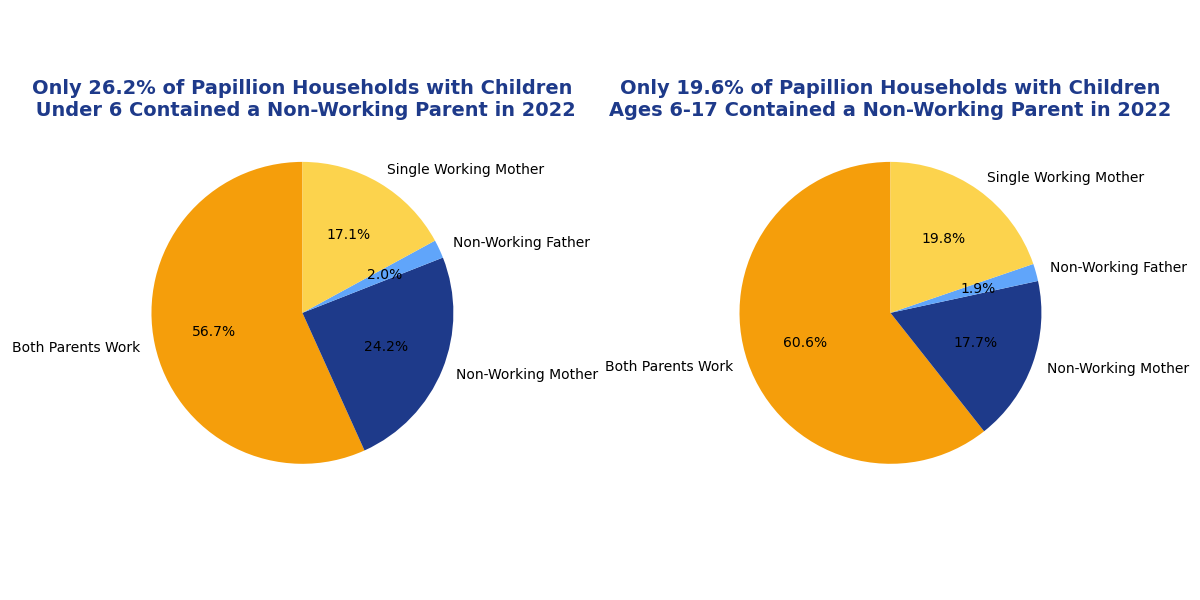

In [11]:
# Uses Papillion color map
papillion_colors = ['#F59E0B', '#1E3A8A', '#60A5FA', '#FCD34D', '#D97706', '#FDBA74'] 

# Creates legend map
household_map = {
    'H_UNDER6_BOTHWORK': 'Both Parents Work',
    'H_UNDER6_FWORK': 'Non-Working Mother', 
    'H_UNDER6_MWORK': 'Non-Working Father',
    'H_UNDER6_SINGLEM': 'Single Working Mother',
    'H_6to17_BOTHWORK': 'Both Parents Work',
    'H_6to17_FWORK': 'Non-Working Mother',
    'H_6to17_MWORK': 'Non-Working Father',
    'H_6to17_SINGLEM': 'Single Working Mother'
}

# Filters sarpy county columns only 
under_6_cols = [col for col in sarpy_2022.columns 
                if 'H_UNDER6' in col and not col.startswith('i') and not col.endswith('STATE')]
age_6_17_cols = [col for col in sarpy_2022.columns 
                 if 'H_6to17' in col and not col.startswith('i') and not col.endswith('STATE')]

# Calculates 2022 Sarpy County totals
under_6_counts_2022 = sarpy_2022[under_6_cols].sum()
age_6_17_counts_2022 = sarpy_2022[age_6_17_cols].sum()

# Creates intuitive labels from mapping
under_6_labels = [household_map[col] for col in under_6_cols]
age_6_17_labels = [household_map[col] for col in age_6_17_cols]

# Creates side-by-side pie charts for Sarpy County 2022
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plots Under 6 households pie chart 
ax1.pie(under_6_counts_2022, 
        labels=under_6_labels, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=papillion_colors[:4])  
ax1.set_title('Only 26.2% of Papillion Households with Children\n Under 6 Contained a \
Non-Working Parent in 2022', 
              fontweight='bold', fontsize=14, color='#1E3A8A')

# Plots 6-17 households pie chart  
ax2.pie(age_6_17_counts_2022, 
        labels=age_6_17_labels,  
        autopct='%1.1f%%', 
        startangle=90,
        colors=papillion_colors[:4])  
ax2.set_title('Only 19.6% of Papillion Households with Children\n\
Ages 6-17 Contained a Non-Working Parent in 2022', 
              fontweight='bold', fontsize=14, color='#1E3A8A')

plt.tight_layout()
plt.show()

### Household Compositions Over Time

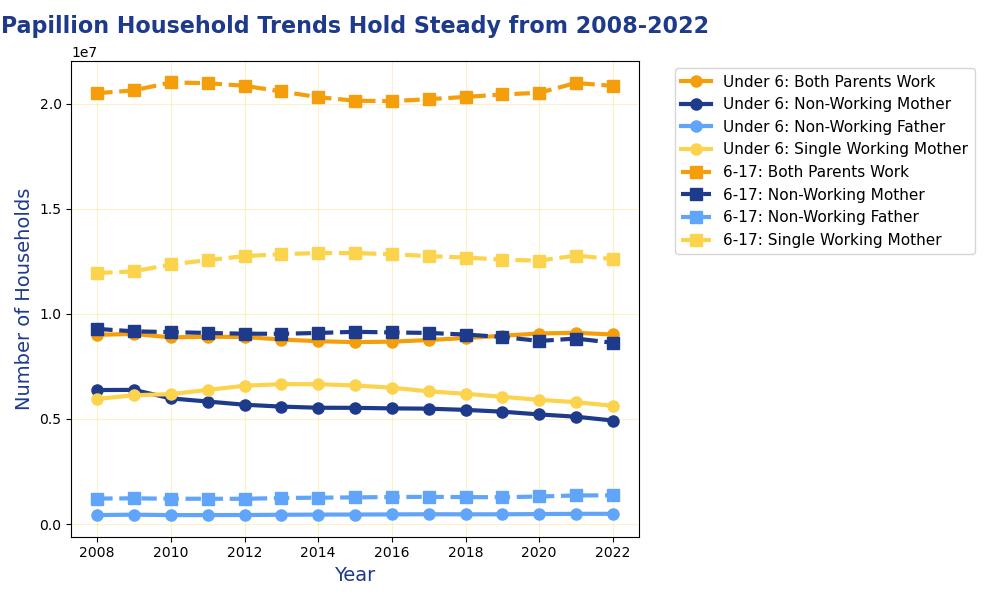

In [12]:
under_6_cols = [col for col in updated_childcare_df.columns 
                if 'H_UNDER6' in col.upper() and not col.startswith('i') and not col.endswith('STATE')]
age_6_17_cols = [col for col in updated_childcare_df.columns 
                 if 'H_6TO17' in col.upper() and not col.startswith('i') and not col.endswith('STATE')]

under_6_counts = updated_childcare_df.groupby('STUDYYEAR')[under_6_cols].sum()
age_6_17_counts = updated_childcare_df.groupby('STUDYYEAR')[age_6_17_cols].sum()

fig, ax = plt.subplots(figsize=(10, 6))

# Plots Under 6 households over time 
for i, col in enumerate(under_6_cols):
    ax.plot(under_6_counts.index, under_6_counts[col], 
            marker='o', linewidth=3, markersize=8,
            color=papillion_colors[i], 
            label=f'Under 6: {household_map[col]}')

# Plots 6-17 households over time
for i, col in enumerate(age_6_17_cols):
    ax.plot(age_6_17_counts.index, age_6_17_counts[col], 
            marker='s', linewidth=3, markersize=8, linestyle='--',
            color=papillion_colors[i], 
            label=f'6-17: {household_map[col]}')

# Papillion styling
ax.set_title('Papillion Household Trends Hold Steady from 2008-2022', 
             fontweight='bold', fontsize=16, color='#1E3A8A', pad=20)
ax.set_xlabel('Year', fontsize=14, color='#1E3A8A')
ax.set_ylabel('Number of Households', fontsize=14, color='#1E3A8A')
ax.grid(True, alpha=0.3, color='#FCD34D')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

### Trial Work-Life Balance Statistics Bar Chart

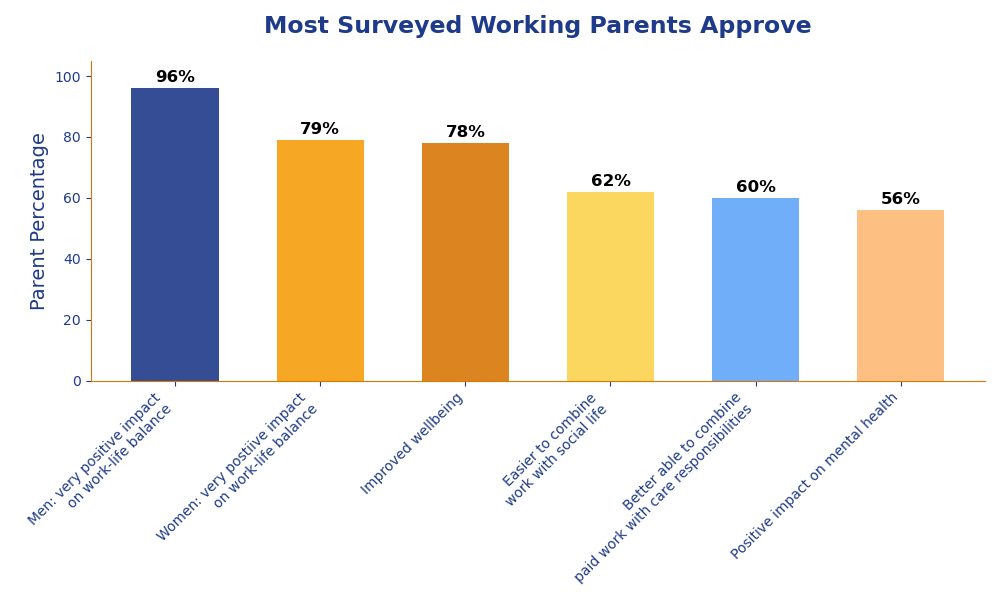

In [13]:
# Creates 4-day week trial data using Perplexity AI simulated data, comes from 
# https://www.4dayweek.com/news-posts/working-parents-ygk8j
trial_data = pd.DataFrame({
    'Metric': ['Better able to combine\npaid work with care responsibilities', 
               'Easier to combine\nwork with social life', 
              'Men: very positive impact\non work-life balance', 
               'Women: very postiive impact\non work-life balance',
              'Positive impact on mental health', 'Improved wellbeing'],
    'Percentage of parents with response (%)': [60, 62, 96, 79, 56, 78]
})

# Sorts in descending order 
trial_data = trial_data.sort_values(
    by='Percentage of parents with response (%)',
    ascending=False
).reset_index(drop=True)

# Continues Papillion Color Scheme
papillion_colors = ['#1E3A8A', '#F59E0B', '#D97706', '#FCD34D', '#60A5FA', '#FDBA74']

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Uses vertical bars instead of horizontal
bars = ax.bar(trial_data['Metric'], trial_data['Percentage of parents with response (%)'], 
              color=papillion_colors, alpha=0.9, width=0.6)

ax.set_ylim(0, 105)
ax.set_title('Most Surveyed Working Parents Approve', 
             fontweight='bold', fontsize=17, pad=20, color='#1E3A8A')
ax.set_ylabel('Parent Percentage', fontsize=14, 
              color='#1E3A8A')
ax.set_xlabel('')

# Rotates x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adds percentages on top of vertical bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, 
            f'{height}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#D97706')
ax.spines['left'].set_color('#D97706')
ax.tick_params(colors='#1E3A8A')

plt.tight_layout()
plt.show()

### Medium Three: Video

### Bar Chart Simulating 20% Drop

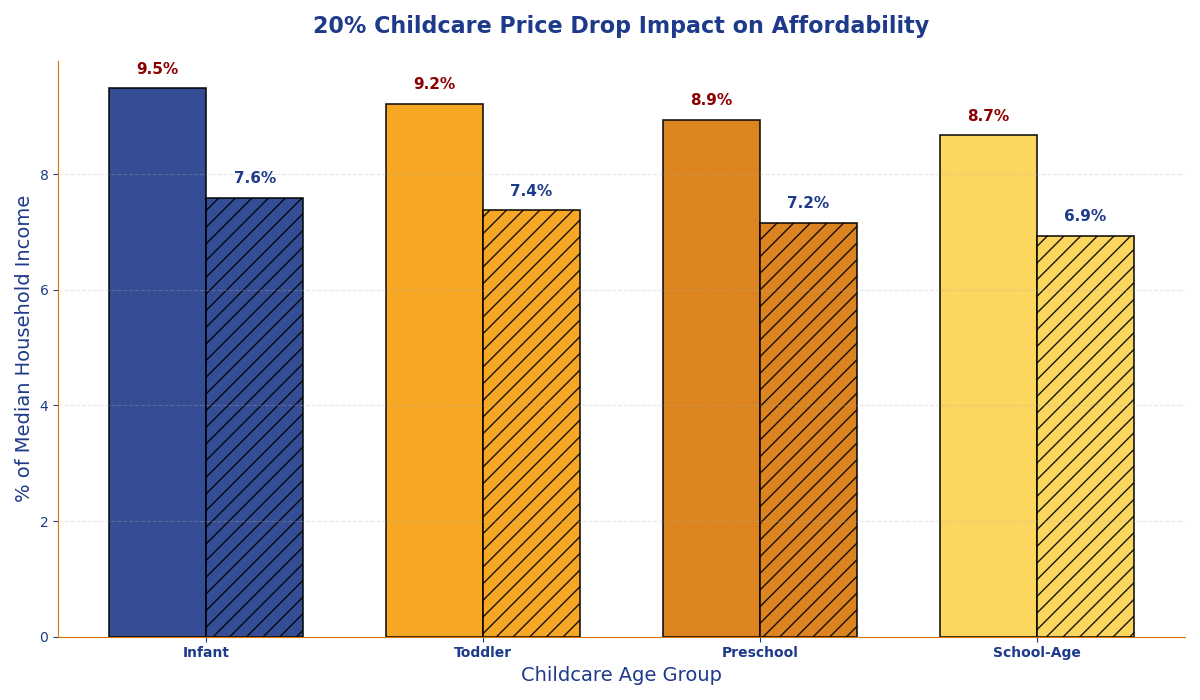

In [14]:
# Continues Papillion color scheme
papillion_colors = {
    'Infant': '#1E3A8A',      
    'Toddler': '#F59E0B',     
    'Preschool': '#D97706',  
    'School-Age': '#FCD34D',  
}

sarpy_data = sarpy_2022[sarpy_2022['COUNTY_NAME'] == 'Sarpy County']
price_cols = ['_75FCCINFANT', '_75FCCTODDLER', '_75FCCPRESCHOOL', '_75FCCSA']
col_mapping = {'_75FCCINFANT': 'Infant', '_75FCCTODDLER': 'Toddler', 
               '_75FCCPRESCHOOL': 'Preschool', '_75FCCSA': 'School-Age'}

# Calculates current more realistic 75th percentile prices as % of median income 
latest_year = sarpy_data['STUDYYEAR'].max()
current_data = sarpy_data[sarpy_data['STUDYYEAR'] == latest_year]
current_pct = (current_data[price_cols].median() * 52 / current_data['MHI'].median()) * 100
current_pct.index = [col_mapping[col] for col in current_pct.index]

# Calculates 20% drop scenario
dropped_pct = current_pct * 0.8

# Combines for plotting
age_groups = list(current_pct.index)
x = np.arange(len(age_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# Create grouped bars with your Papillion colors
bars1 = ax.bar(x - width/2, current_pct.values, width, 
               label='Current 75th %ile', color=[papillion_colors[group] for group in age_groups],
               alpha=0.9, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, dropped_pct.values, width,
               label='20% Price Drop', color=[papillion_colors[group] + '80' for group in age_groups], 
               alpha=0.9, edgecolor='black', linewidth=1.2, hatch='//')

ax.set_title('20% Childcare Price Drop Impact on Affordability', 
             fontweight='bold', fontsize=16, color='#1E3A8A', pad=20)
ax.set_ylabel('% of Median Household Income', fontsize=14, color='#1E3A8A')
ax.set_xlabel('Childcare Age Group', fontsize=14, color='#1E3A8A')
ax.set_xticks(x)
ax.set_xticklabels(age_groups, rotation=0, fontweight='bold')

ax.tick_params(colors='#1E3A8A')
ax.spines['bottom'].set_color('#D97706')
ax.spines['left'].set_color('#D97706')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adds value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    h1 = bar1.get_height()
    h2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2, h1 + 0.2, f'{h1:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11, color='darkred')
    ax.text(bar2.get_x() + bar2.get_width()/2, h2 + 0.2, f'{h2:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11, color='#1E3A8A')

plt.tight_layout()
plt.show()

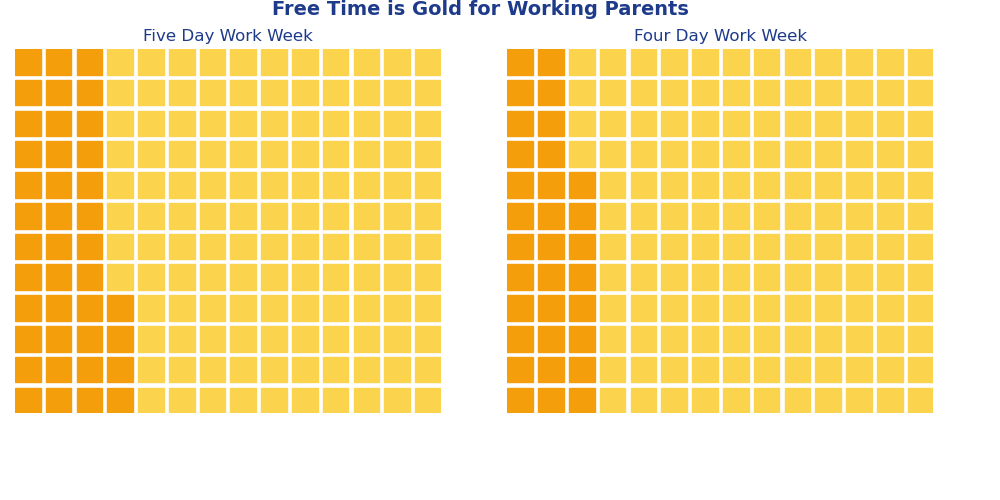

In [15]:
# Five day work week
work_5day = 40
free_5day = 128

# Four day work week
work_4day = 32
free_4day = 136 

# Plots two waffle plots side by side
plt.figure(
    FigureClass=Waffle,
    plots={
        121: {  
            'values': {'Work': work_5day, 'Free Time': free_5day},
            'colors': ['#F59E0B', '#FCD34D'],  
            'title': {'label': 'Five Day Work Week', 'loc': 'center', 'fontsize': 12, 
                     'color': '#1E3A8A'}
        },
        122: {  
            'values': {'Work': work_4day, 'Free Time': free_4day},
            'colors': ['#F59E0B', '#FCD34D'],
            'title': {'label': 'Four Day Work Week', 'loc': 'center', 'fontsize': 12, 
                     'color': '#1E3A8A'}
        }
    },
    rows=12,
    columns=14,  
    legend={'loc': 'lower center', 'bbox_to_anchor': (0.5, -0.4), 'ncol': 2},  
    figsize=(10, 5) 
)

# Details centered title
plt.suptitle('Free Time is Gold for Working Parents', 
             fontsize=14,  
             fontweight='bold', 
             color='#1E3A8A',
             x=0.48, y=1)  

plt.tight_layout()
plt.show()

## Dashboard Code

In [16]:
# Filters for Sarpy County Data
sarpy_2022 = updated_childcare_df[
    (updated_childcare_df["STATE_ABBREVIATION"] == "NE") &
    (updated_childcare_df["COUNTY_NAME"].str.contains("Sarpy", case=False))
]

# Establishes Papillion color scheme
papillion_colors = {
    'Infant': '#1E3A8A', 'Toddler': '#F59E0B', 'Preschool': '#D97706', 
    'School-Age': '#FCD34D', 'projected': '#DC2626', 'hhs_threshold': '#6B7280',
    'subsidy_cap': '#EA580C', 'saved': '#F59E0B', 'background': '#FCD34D'
}

sarpy_data = sarpy_2022[sarpy_2022['COUNTY_NAME'] == 'Sarpy County'].copy()
price_cols = ['_75FCCINFANT', '_75FCCTODDLER', '_75FCCPRESCHOOL', '_75FCCSA']
col_mapping = {
    '_75FCCINFANT': 'Infant',
    '_75FCCTODDLER': 'Toddler', 
    '_75FCCPRESCHOOL': 'Preschool',
    '_75FCCSA': 'School-Age'
}

proportions = (sarpy_data.groupby('STUDYYEAR')[price_cols].median() * 52).div(
    sarpy_data.groupby('STUDYYEAR')['MHI'].median(), axis=0) * 100
proportions.columns = [col_mapping[col] for col in proportions.columns]
proportions = proportions[proportions.index >= 2016]

# Trial data 
trial_data = pd.DataFrame({
    'Family Savings Metric': [
        'Childcare expense reduction (1 fewer day/week)',
        'Employee sick leave/absenteeism reduced',
        'Commuting trips eliminated (20% fewer miles)', 
        'Gas cost savings (Nebraska average commute 28mi)'
    ],
    'Estimated Savings': [20, 65, 20, 15]
}).sort_values('Estimated Savings', ascending=True).reset_index(drop=True)

# Creates mapping for age data
sarpy_2022_data = sarpy_data[sarpy_data['STUDYYEAR'] == 2022]
sarpy_2022_row = sarpy_2022_data.iloc[0]
weekly_costs = {
    0: sarpy_2022_row['_75FCCINFANT'],     
    1: sarpy_2022_row['_75FCCTODDLER'],       
    3: sarpy_2022_row['_75FCCPRESCHOOL'],  
    6: sarpy_2022_row['_75FCCSA']           
}

def get_weekly_cost(age):
    """Returns weekly childcare cost by age group"""
    ages = sorted(weekly_costs.keys())
    for i, a in enumerate(ages):
        if age <= a: 
            return weekly_costs[a]
    return weekly_costs[ages[-1]]

def get_slider_fig(age=2):
    years_remaining = max(0, 18 - age)
    years_saved = years_remaining * 52 / 365  
    
    weekly_cost = get_weekly_cost(age)
    weekly_savings = weekly_cost * 0.2
    total_dollars = years_remaining * weekly_savings * 52 / 1000
    
    fig = go.Figure()
    
    # Family Time bar
    fig.add_trace(go.Bar(
        y=['Family Time'], x=[years_saved], orientation='h',
        marker=dict(color=papillion_colors['saved'], opacity=0.9),
        text=f'{years_saved:.1f} years', textposition='outside',
        textfont=dict(size=14, family='Arial Black', color='black'),
        showlegend=False
    ))
    
    # Dollars bar 
    fig.add_trace(go.Bar(
        y=['Dollars<br>Reclaimed'], x=[total_dollars], orientation='h',
        marker=dict(color=papillion_colors['saved'], opacity=0.9),
        text=f'${total_dollars:.0f}K', textposition='outside',
        textfont=dict(size=14, family='Arial Black', color='black'),
        showlegend=False
    ))
    
    fig.update_layout(
        title=dict(
            text='How Much Can Your Family Save?<br>(Add Totals Per Child)',
            font=dict(size=18, family='Arial Black', color='#1E3A8A')
        ),
        height=500,
        template='plotly_white',
        font=dict(color='#1E3A8A')
    )
    return fig

def get_family_savings_fig():
    fig = go.Figure()
    colors = ['#1E3A8A', '#F59E0B', '#D97706', '#FCD34D']
    
    for i, row in trial_data.iterrows():
        fig.add_trace(go.Bar(
            x=[row['Estimated Savings']],
            y=[row['Family Savings Metric']], 
            orientation='h',
            marker=dict(color=colors[i], opacity=0.9),
            text=f'{row["Estimated Savings"]}%',
            textposition='outside',
            textfont=dict(size=12, family='Arial Black', color='black'),
            name=row['Family Savings Metric'],
            showlegend=False
        ))
    
    fig.update_layout(
        title=dict(
            text="Families Save with a Four-Day Week", 
            font=dict(size=18, family='Arial Black', color='#1E3A8A')
        ),
        xaxis_title="Estimated Savings (%)",
        yaxis_title="",
        template='plotly_white',
        font=dict(color='#1E3A8A'),
        height=500,
        margin=dict(l=100, r=20, t=80, b=20)
    )
    return fig

# Creates responsive layout for PDF
app = Dash(__name__)

app.layout = html.Div([
    html.H1(
        "Papillion Families Can Reclaim Time & Money with Four-Day Weeks", 
        style={
            'textAlign': 'center',
            'color': '#1E3A8A',
            'fontFamily': 'Arial Black'
        }
    ),
    
    html.Div([
        html.Span("Learn more at "),
        html.A(
            "www.papillion-4-day.com",
            href="https://www.papillion-4-day.com",
            style={
                'color': '#1E3A8A',
                'fontWeight': 'bold',
                'textDecoration': 'none',
                'marginRight': '8px'
            }
        ),
        html.Img(
            src=app.get_asset_url("papillion.png"),
            style={
                'height': '100px',
                'verticalAlign': 'middle'
            }
        ),
    ], style={
        'textAlign': 'center',
        'fontSize': '16px',
        'color': '#6B7280', 
        'marginBottom': '30px',
        'fontFamily': 'Arial',
        'whiteSpace': 'nowrap'
    }),
    
    # Tabs container
    html.Div([
        dcc.Tabs(id="tabs", children=[
            dcc.Tab(label='Is Childcare Affordable?', children=[
                dcc.Graph(
                    figure=px.line(
                        proportions,
                        color_discrete_map=papillion_colors,
                        title=(
                            "Papillion Families Still Pay 1.4x HHS Affordability"
                            "<br>Threshold Despite 2019 Subsidy Caps"
                        ),
                        labels={
                            'value': '% of Median Household Income',
                            'STUDYYEAR': 'Study Year'
                        }
                    )
                    .add_hline(
                        y=7,
                        line_dash="dot",
                        line_color=papillion_colors['hhs_threshold'], 
                        annotation_text="HHS Threshold"
                    )
                    .add_vline(
                        x=2019,
                        line_dash="dot",
                        line_color=papillion_colors['subsidy_cap'], 
                        annotation_text="2019 Subsidy Cap"
                    )
                    .update_traces(line=dict(width=4))
                    .update_yaxes(rangemode="tozero") 
                    .update_layout(
                        template='plotly_white',
                        font=dict(color='#1E3A8A'),
                        height=500
                    )
                )
            ]),
            
            dcc.Tab(label='Subsidy Caps Helped, But Families Could Be Saving More', children=[
                dcc.Graph(figure=get_family_savings_fig())
            ]),
            
            dcc.Tab(label='Time and Money Saved Simulator', children=[
                html.Div([
                    dcc.Graph(id='slider-plot', figure=get_slider_fig(2)),
                    html.Div([
                        html.Span(
                            "Child Age: ",
                            style={'fontWeight': 'bold', 'color': '#1E3A8A'}
                        ),
                        dcc.Slider(
                            id='age-slider',
                            min=0,
                            max=17,
                            value=2,
                            step=1,
                            marks={i: str(i) for i in range(0, 18, 2)},
                            tooltip={'placement': 'bottom', 'always_visible': True}
                        )
                    ], style={'padding': '20px', 'textAlign': 'center'})
                ])
            ])
        ], style={
            'width': '95%', 
            'maxWidth': '1200px', 
            'margin': '0 auto 20px auto',
            'fontFamily': 'Arial'
        })
    ], style={
        'maxWidth': '1400px',
        'margin': '0 auto',
        'padding': '0 20px'
    }),
    
    html.Footer(
        "Data: Sarpy County Childcare 2022 + 4-Day Week Global Trials | Papillion, NE", 
        style={
            'textAlign': 'center',
            'color': 'gray',
            'padding': '30px'
        }
    )
], style={
    'padding': '30px 5%',
    'backgroundColor': '#F8FAFC', 
    'fontFamily': 'Arial',
    'maxWidth': '1600px',
    'margin': '0 auto'
})

@callback(Output('slider-plot', 'figure'), Input('age-slider', 'value'))
def update_slider(age):
    return get_slider_fig(age)

if __name__ == '__main__':
    app.run(debug=True)